# Experiment Analysis

Compares models on both the `full` and `minimal` ablations.
Only features with data for **all** enabled models **and all ablations** are included.

**Terminology:**
- **feature** — one buggy Eiffel feature to fix; one record in the JSONL results.
- **attempt** — one fix iteration: AutoProof runs to get the error → LLM generates a fix → fix is applied → AutoProof verifies the result. Corresponds to `llm_interactions` in the data.
- **verification** — one AutoProof/Boogie/z3 execution (at least once per attempt).
- **ablation** — prompt configuration: `full` = all prompt parts enabled, `minimal` = all disabled.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
MODELS = [
    "openai/gpt-5-nano",
    "anthropic/claude-sonnet-4.6",
    "poolside/laguna-xs.2:free",
]
MODEL_LABELS = {
    "openai/gpt-5-nano":           "GPT-5 nano",
    "anthropic/claude-sonnet-4.6": "Claude Sonnet 4.6",
    "poolside/laguna-xs.2:free":   "Laguna XS",
}
ABLATIONS       = ["full", "minimal"]
ABLATION_LABELS = {"full": "Full", "minimal": "Minimal"}
RESULTS_DIR     = Path("results")
MAX_ATTEMPTS    = 10
# Paul Tol colorblind-safe palette
COLORS = ["#4477AA", "#EE6677", "#228833"]
# Ablation distinction via hatch only (color encodes model)
ABLATION_HATCH = {"full": "", "minimal": "/"}

In [3]:
# ── Data loading ──────────────────────────────────────────────────────────────
def slug(m: str) -> str:
    return m.replace("/", "_").replace(":", "_")


def load_records_multi(results_dir, models, ablations):
    """Return {(model, ablation): [records]}."""
    out = {}
    for model in models:
        for ablation in ablations:
            records = []
            for ds_dir in sorted(results_dir.iterdir()):
                if not ds_dir.is_dir() or ds_dir.name == "html":
                    continue
                jf = ds_dir / slug(model) / f"{ablation}.jsonl"
                if not jf.exists():
                    continue
                for line in jf.read_text().splitlines():
                    line = line.strip()
                    if line and not line.startswith(">>"):
                        try:
                            rec = json.loads(line)
                            rec["dataset"] = ds_dir.name
                            records.append(rec)
                        except json.JSONDecodeError:
                            pass
            out[(model, ablation)] = records
    return out


def common_features(records_map):
    """Features present in ALL keys of records_map."""
    sets = [
        {(r["dataset"], r["class_name"], r["feature_name"]) for r in recs}
        for recs in records_map.values()
    ]
    return set.intersection(*sets) if sets else set()


def filter_by(records_map, key_set):
    return {k: [r for r in recs
                if (r["dataset"], r["class_name"], r["feature_name"]) in key_set]
            for k, recs in records_map.items()}


# ── Load everything ────────────────────────────────────────────────────────────
raw_ma = load_records_multi(RESULTS_DIR, MODELS, ABLATIONS)
common_ma = common_features(raw_ma)
data_ma = filter_by(raw_ma, common_ma)

# Drop 0-attempt features (dataset quality issue) and re-intersect across all combos
n_zero_ma = {k: sum(1 for r in recs if r["llm_interactions"] == 0)
             for k, recs in data_ma.items()}
data_ma = {k: [r for r in recs if r["llm_interactions"] > 0]
           for k, recs in data_ma.items()}
common_final = common_features(data_ma)
data_ma = filter_by(data_ma, common_final)

print(f"Common features across ALL (model × ablation) combos: {len(common_ma)}")
max_zero = max(n_zero_ma.values()) if n_zero_ma else 0
print(f"  dropped — 0-attempt: {max_zero}")
print(f"  remaining for analysis: {len(common_final)}\n")
print(f"{'(Model, Ablation)':<45} {'loaded':>6}  {'final':>6}")
for abl in ABLATIONS:
    for m in MODELS:
        k = (m, abl)
        print(f"  ({MODEL_LABELS[m]}, {ABLATION_LABELS[abl]})"
              f"{' ' * max(1, 40 - len(MODEL_LABELS[m]))}"
              f"{len(raw_ma[k]):>6}  {len(data_ma[k]):>6}")

Common features across ALL (model × ablation) combos: 546
  dropped — 0-attempt: 7
  remaining for analysis: 539

(Model, Ablation)                             loaded   final
  (GPT-5 nano, Full)                                 546     539
  (Claude Sonnet 4.6, Full)                          546     539
  (Laguna XS, Full)                                  546     539
  (GPT-5 nano, Minimal)                                 546     539
  (Claude Sonnet 4.6, Minimal)                          546     539
  (Laguna XS, Minimal)                                  546     539


### OpenRouter Wait Times per Attempt

Sporadic queue delays only appear in the **tail** of the wait-time distribution.
The plots below combine data from both ablations (all records, not limited to common features) to maximise tail coverage.

Each data point is one attempt's OpenRouter round-trip time (`ai_request_time_seconds`).

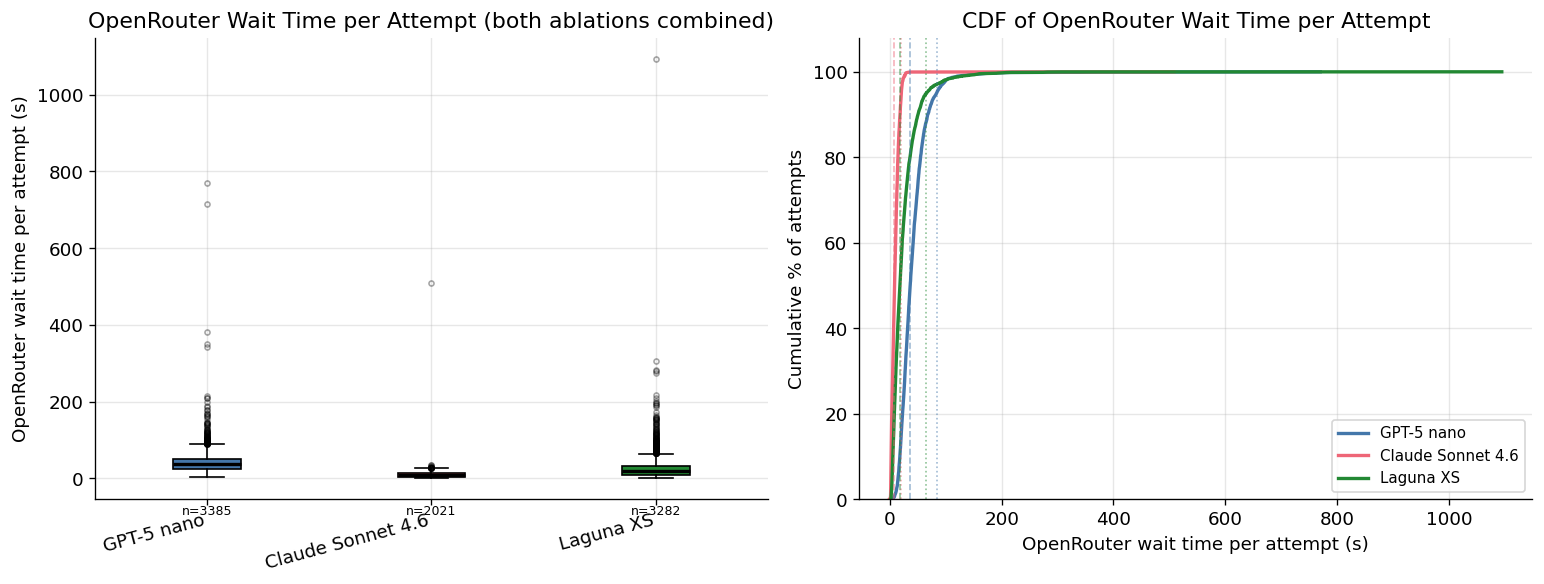

Model                          attempts      p50      p75      p95      max
  GPT-5 nano                       3385     36.6     51.2     83.8    769.6
  Claude Sonnet 4.6                2021      8.6     13.6     20.8    508.1
  Laguna XS                        3282     18.3     31.8     65.5   1094.1


In [4]:
# Collect per-attempt OpenRouter wait times from all ablations (better tail coverage)
ix_rows = []
for m in MODELS:
    for abl in ABLATIONS:
        for rec in raw_ma[(m, abl)]:
            for ix in (rec.get("interactions") or []):
                t = ix.get("ai_request_time_seconds")
                if t is not None:
                    ix_rows.append({"model": m, "label": MODEL_LABELS[m], "wait": t})
df_ix = pd.DataFrame(ix_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
box_data = [df_ix[df_ix["model"] == m]["wait"].values for m in MODELS]
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                flierprops=dict(marker="o", markersize=3, alpha=0.35),
                showfliers=True)
for patch, c in zip(bp["boxes"], COLORS):
    patch.set_facecolor(c)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("OpenRouter wait time per attempt (s)")
ax.set_title("OpenRouter Wait Time per Attempt (both ablations combined)")
for i, (m, d) in enumerate(zip(MODELS, box_data), 1):
    if len(d):
        ax.text(i, -ax.get_ylim()[1] * 0.06,
                f"n={len(d)}", ha="center", va="top", fontsize=7.5)

ax = axes[1]
for i, m in enumerate(MODELS):
    d = np.sort(df_ix[df_ix["model"] == m]["wait"].values)
    if len(d) == 0:
        continue
    cdf = np.arange(1, len(d) + 1) / len(d) * 100
    ax.plot(d, cdf, color=COLORS[i], linewidth=2, label=MODEL_LABELS[m])
ax.set_xlabel("OpenRouter wait time per attempt (s)")
ax.set_ylabel("Cumulative % of attempts")
ax.set_title("CDF of OpenRouter Wait Time per Attempt")
ax.set_ylim(0, 108)
ax.legend(fontsize=9)
for i, m in enumerate(MODELS):
    d = df_ix[df_ix["model"] == m]["wait"].values
    if len(d) == 0:
        continue
    for pct, ls in [(50, "--"), (95, ":")]:
        v = np.percentile(d, pct)
        ax.axvline(v, color=COLORS[i], linestyle=ls, linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig("analysis_or_queue.png", bbox_inches="tight")
plt.show()

print(f"{'Model':<30} {'attempts':>8}  {'p50':>7}  {'p75':>7}  {'p95':>7}  {'max':>7}")
for m in MODELS:
    d = df_ix[df_ix["model"] == m]["wait"].values
    if len(d):
        print(f"  {MODEL_LABELS[m]:<28} {len(d):>8}  "
              f"{np.percentile(d,50):>7.1f}  {np.percentile(d,75):>7.1f}  "
              f"{np.percentile(d,95):>7.1f}  {np.max(d):>7.1f}")

---

## Results: Full vs Minimal Prompt Ablation

Within each model group: left bar (solid) = `full` ablation, right bar (hatched `////`) = `minimal`.
All charts use the same common feature set.

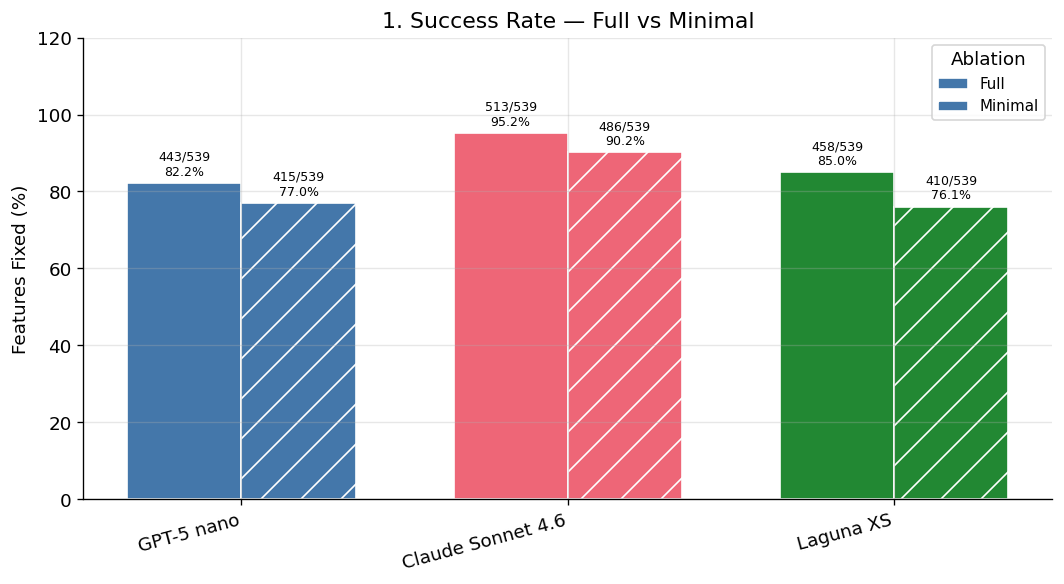


Model                         Ablation   fixed   total   rate %
  GPT-5 nano                      Full     443     539     82.2
  Claude Sonnet 4.6               Full     513     539     95.2
  Laguna XS                       Full     458     539     85.0
  GPT-5 nano                   Minimal     415     539     77.0
  Claude Sonnet 4.6            Minimal     486     539     90.2
  Laguna XS                    Minimal     410     539     76.1


In [5]:
### 1.  Success Rate
fig, ax = plt.subplots(figsize=(9, 5))

n_m = len(MODELS)
n_a = len(ABLATIONS)
group_w = 0.7
bar_w   = group_w / n_a
x = np.arange(n_m)

for ai, abl in enumerate(ABLATIONS):
    offset  = (ai - n_a / 2 + 0.5) * bar_w
    n_succ  = [sum(r["success"] for r in data_ma[(m, abl)]) for m in MODELS]
    n_total = [len(data_ma[(m, abl)]) for m in MODELS]
    rates   = [s / t * 100 if t else 0 for s, t in zip(n_succ, n_total)]
    bars = ax.bar(x + offset, rates, bar_w,
                  color=COLORS, hatch=ABLATION_HATCH[abl], edgecolor="white",
                  label=ABLATION_LABELS[abl])
    for bar, s, t, r in zip(bars, n_succ, n_total, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
                f"{s}/{t}\n{r:.1f}%", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("Features Fixed (%)")
ax.set_ylim(0, 120)
ax.set_title("1. Success Rate — Full vs Minimal")
ax.legend(title="Ablation", fontsize=9)

plt.tight_layout()
plt.savefig("analysis_1_success.png", bbox_inches="tight")
plt.show()

print(f"\n{'Model':<28}  {'Ablation':>8}  {'fixed':>6}  {'total':>6}  {'rate %':>7}")
for abl in ABLATIONS:
    for m in MODELS:
        recs = data_ma[(m, abl)]
        s = sum(r["success"] for r in recs)
        t = len(recs)
        print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  {s:>6}  {t:>6}  {s/t*100:>7.1f}")

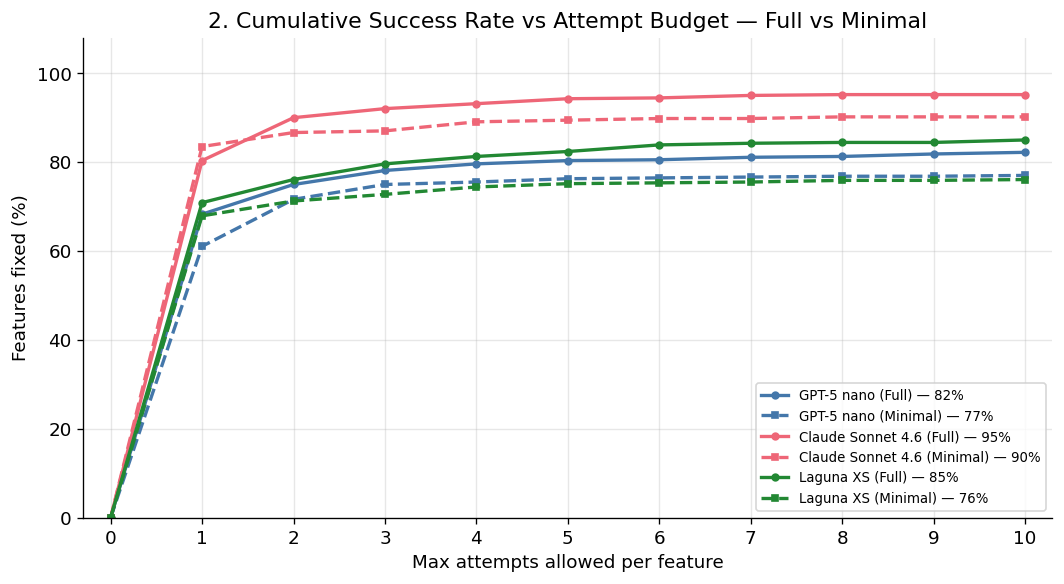

In [6]:
### 2.  Cumulative Success Rate vs Attempt Budget
fig, ax = plt.subplots(figsize=(9, 5))
xs = list(range(0, MAX_ATTEMPTS + 1))

linestyles = {"full": "-", "minimal": "--"}
markers    = {"full": "o", "minimal": "s"}
for ci, m in enumerate(MODELS):
    for abl in ABLATIONS:
        recs = data_ma[(m, abl)]
        n = len(recs)
        if n == 0:
            continue
        ys = [sum(1 for r in recs if r["success"] and r["llm_interactions"] <= k) / n * 100
              for k in xs]
        ax.plot(xs, ys,
                color=COLORS[ci], linewidth=2,
                linestyle=linestyles[abl], marker=markers[abl], markersize=4,
                label=f"{MODEL_LABELS[m]} ({ABLATION_LABELS[abl]}) — {ys[-1]:.0f}%")

ax.set_xlabel("Max attempts allowed per feature")
ax.set_ylabel("Features fixed (%)")
ax.set_title("2. Cumulative Success Rate vs Attempt Budget — Full vs Minimal")
ax.set_xticks(xs)
ax.set_xlim(-0.3, MAX_ATTEMPTS + 0.3)
ax.set_ylim(0, 108)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("analysis_2_cumulative.png", bbox_inches="tight")
plt.show()

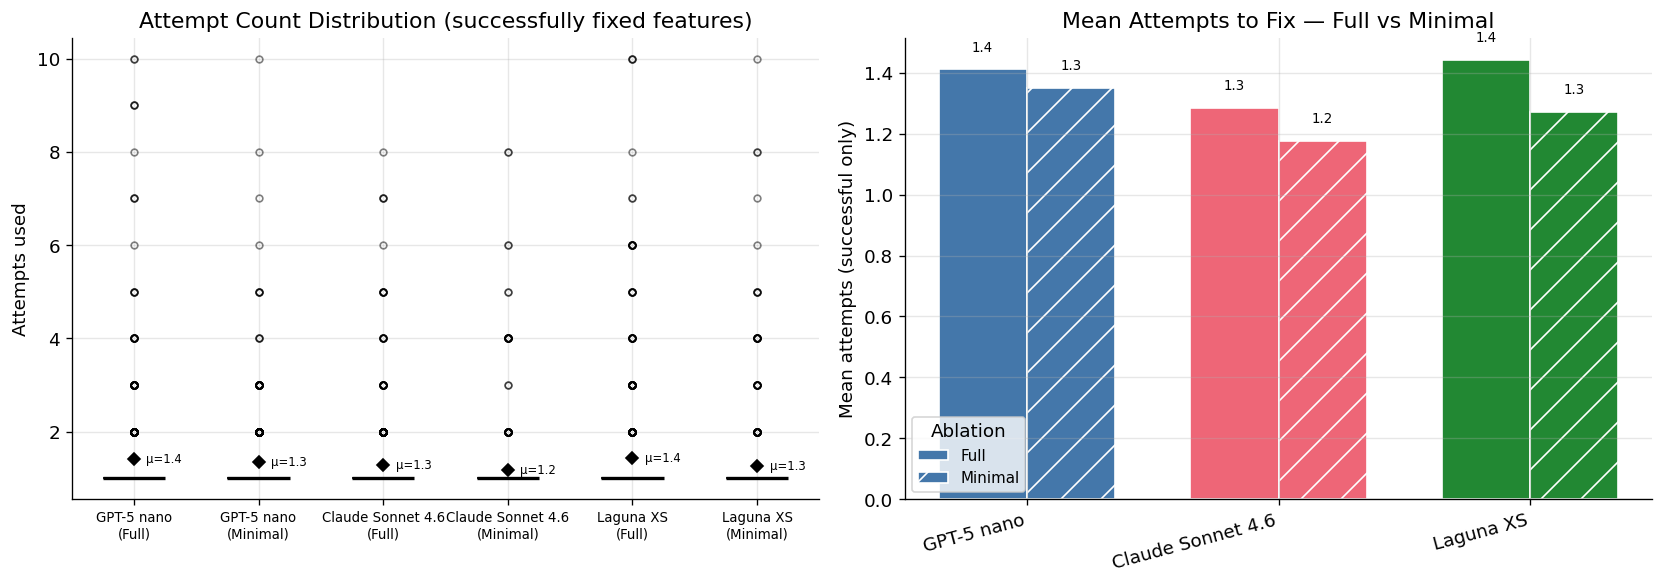


Model                         Ablation   fixed    mean   median   max
  GPT-5 nano                      Full     443     1.4      1.0    10
  Claude Sonnet 4.6               Full     513     1.3      1.0     8
  Laguna XS                       Full     458     1.4      1.0    10
  GPT-5 nano                   Minimal     415     1.3      1.0    10
  Claude Sonnet 4.6            Minimal     486     1.2      1.0     8
  Laguna XS                    Minimal     410     1.3      1.0    10


In [7]:
### 3.  Attempt Count Distribution — Full vs Minimal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: boxplots — 6 boxes in model-paired order
box_vals, box_labels, box_colors, box_hatches = [], [], [], []
for ci, m in enumerate(MODELS):
    for abl in ABLATIONS:
        vals = [r["llm_interactions"] for r in data_ma[(m, abl)]
                if r["success"] and r["llm_interactions"] > 0]
        box_vals.append(vals)
        box_labels.append(f"{MODEL_LABELS[m]}\n({ABLATION_LABELS[abl]})")
        box_colors.append(COLORS[ci])
        box_hatches.append(ABLATION_HATCH[abl])

ax = axes[0]
bp = ax.boxplot(box_vals, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                flierprops=dict(marker="o", markersize=4, alpha=0.5))
for patch, color, hatch in zip(bp["boxes"], box_colors, box_hatches):
    patch.set_facecolor(color)
    patch.set_hatch(hatch)
ax.set_xticklabels(box_labels, fontsize=8)
ax.set_ylabel("Attempts used")
ax.set_title("Attempt Count Distribution (successfully fixed features)")
for i, vals in enumerate(box_vals, 1):
    if vals:
        mn = np.mean(vals)
        ax.plot(i, mn, "D", color="black", zorder=5, ms=5)
        ax.text(i + 0.1, mn, f"μ={mn:.1f}", va="center", fontsize=7)

# Right: mean attempts per model, full vs minimal
ax = axes[1]
bar_w = 0.35
xpos  = np.arange(n_m)
for ai, abl in enumerate(ABLATIONS):
    means = []
    for m in MODELS:
        vals = [r["llm_interactions"] for r in data_ma[(m, abl)]
                if r["success"] and r["llm_interactions"] > 0]
        means.append(np.mean(vals) if vals else 0)
    offset = (ai - len(ABLATIONS) / 2 + 0.5) * bar_w
    bars = ax.bar(xpos + offset, means, bar_w,
                  color=COLORS, hatch=ABLATION_HATCH[abl], edgecolor="white",
                  label=ABLATION_LABELS[abl])
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{v:.1f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(xpos)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("Mean attempts (successful only)")
ax.set_title("Mean Attempts to Fix — Full vs Minimal")
ax.legend(title="Ablation", fontsize=9)

plt.tight_layout()
plt.savefig("analysis_3_attempts.png", bbox_inches="tight")
plt.show()

print(f"\n{'Model':<28}  {'Ablation':>8}  {'fixed':>6}  {'mean':>6}  {'median':>7}  {'max':>4}")
for abl in ABLATIONS:
    for m in MODELS:
        a = [r["llm_interactions"] for r in data_ma[(m, abl)]
             if r["success"] and r["llm_interactions"] > 0]
        if a:
            print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  {len(a):>6}  "
                  f"{np.mean(a):>6.1f}  {np.median(a):>7.1f}  {max(a):>4}")

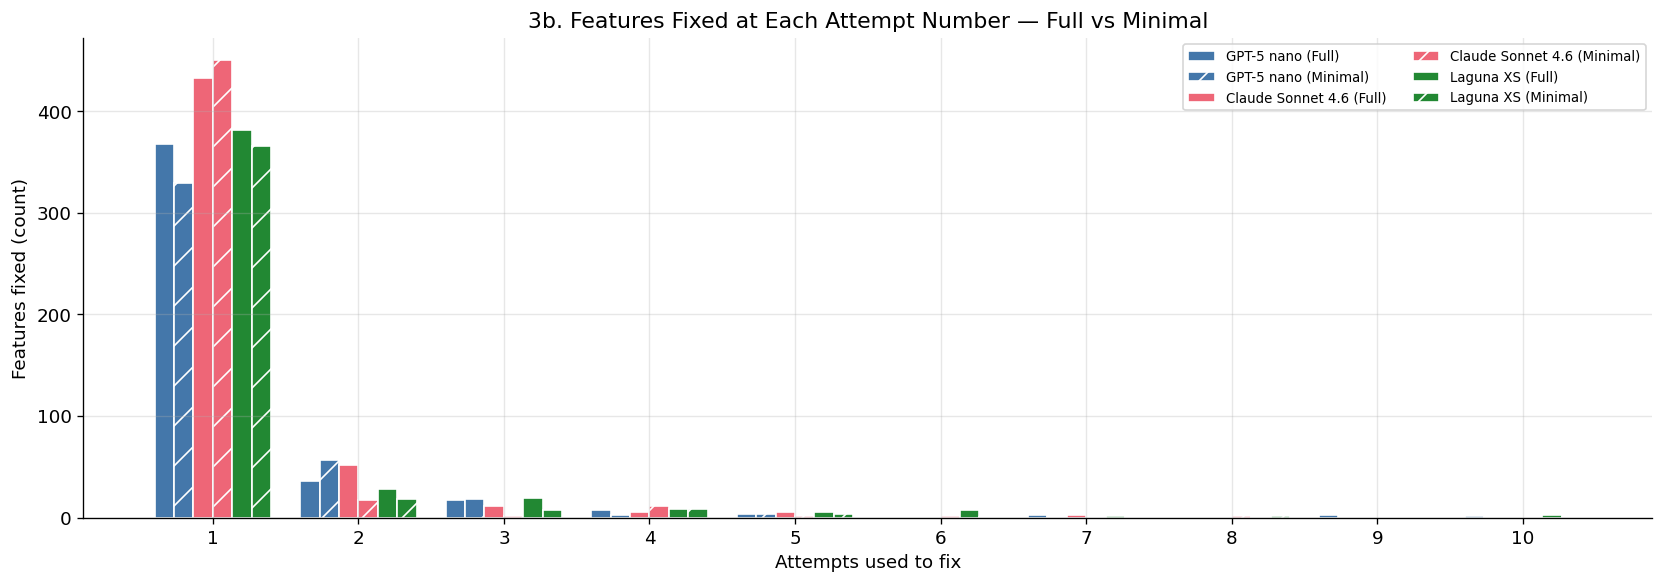

In [8]:
### 3b.  Features Fixed at Each Attempt Number — Full vs Minimal
xs    = np.arange(1, MAX_ATTEMPTS + 1)
combos = [(m, abl) for m in MODELS for abl in ABLATIONS]   # 6 bars per x
n_c    = len(combos)
bar_w  = 0.8 / n_c

fig, ax = plt.subplots(figsize=(14, 5))
for i, (m, abl) in enumerate(combos):
    counts = [
        sum(1 for r in data_ma[(m, abl)]
            if r["success"] and r["llm_interactions"] == k)
        for k in xs
    ]
    offset = (i - n_c / 2 + 0.5) * bar_w
    ci = MODELS.index(m)
    ax.bar(xs + offset, counts, bar_w,
           color=COLORS[ci], hatch=ABLATION_HATCH[abl], edgecolor="white",
           label=f"{MODEL_LABELS[m]} ({ABLATION_LABELS[abl]})")

ax.set_xlabel("Attempts used to fix")
ax.set_ylabel("Features fixed (count)")
ax.set_title("3b. Features Fixed at Each Attempt Number — Full vs Minimal")
ax.set_xticks(xs)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("analysis_3b_fixed_per_attempt.png", bbox_inches="tight")
plt.show()

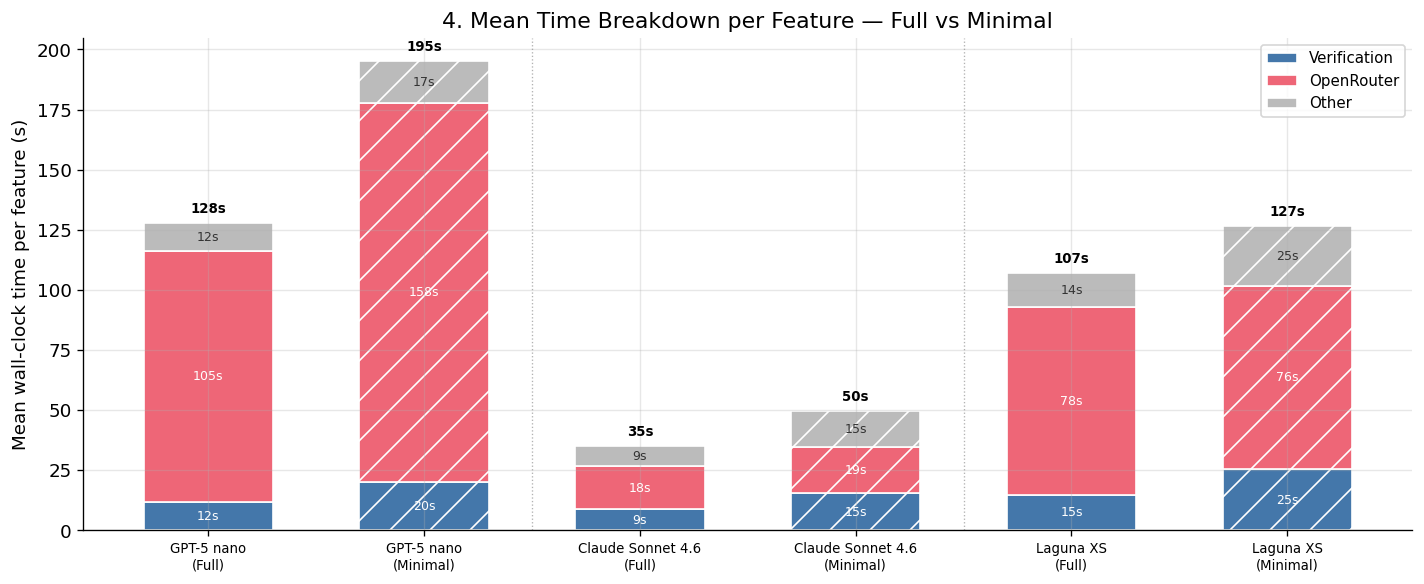


Model                         Ablation     total     verif      OR    other
  GPT-5 nano                      Full     127.8      11.6   104.6     11.6
  Claude Sonnet 4.6               Full      35.2       8.6    17.9      8.6
  Laguna XS                       Full     107.0      14.7    78.3     14.0
  GPT-5 nano                   Minimal     195.2      20.1   157.5     17.5
  Claude Sonnet 4.6            Minimal      49.6      15.3    19.1     15.2
  Laguna XS                    Minimal     126.7      25.4    76.2     25.0


In [9]:
### 4.  Time Breakdown per Feature — Full vs Minimal
time_rows_abl = []
for abl in ABLATIONS:
    for m in MODELS:
        for rec in data_ma[(m, abl)]:
            ixs   = rec.get("interactions") or []
            total = rec.get("total_elapsed_time_seconds") or 0.0
            verif = sum((ix.get("verification_time_seconds") or 0.0) for ix in ixs)
            llm   = sum((ix.get("ai_request_time_seconds")  or 0.0) for ix in ixs)
            other = max(0.0, total - verif - llm)
            time_rows_abl.append({
                "model": m, "ablation": abl,
                "combo": f"{m}|{abl}",
                "total": total, "verification": verif, "openrouter": llm, "other": other,
            })
df_ta = pd.DataFrame(time_rows_abl)

combo_keys    = [f"{m}|{abl}" for m in MODELS for abl in ABLATIONS]
combo_labels  = [f"{MODEL_LABELS[m]}\n({ABLATION_LABELS[abl]})" for m in MODELS for abl in ABLATIONS]
combo_colors  = [COLORS[ci] for ci, m in enumerate(MODELS) for abl in ABLATIONS]
combo_hatches = [ABLATION_HATCH[abl] for m in MODELS for abl in ABLATIONS]
x = np.arange(len(combo_labels))

fig, ax = plt.subplots(figsize=(12, 5))
means_ta = df_ta.groupby("combo")[["verification", "openrouter", "other"]].mean().reindex(combo_keys)
tc = [("verification", "#4477AA", "Verification"),
      ("openrouter",   "#EE6677", "OpenRouter"),
      ("other",        "#BBBBBB", "Other")]
bottom = np.zeros(len(combo_labels))

for col, tc_col, lbl in tc:
    vals = means_ta[col].values
    for xi, (v, b, color, hatch) in enumerate(zip(vals, bottom, combo_colors, combo_hatches)):
        ax.bar(xi, v, 0.6, bottom=b, color=tc_col, hatch=hatch, edgecolor="white",
               label=lbl if xi == 0 else None)
        if v > 2:
            ax.text(xi, b + v / 2, f"{v:.0f}s", ha="center", va="center", fontsize=7.5,
                    color="white" if tc_col != "#BBBBBB" else "#333333")
    bottom += vals

for xi, total in enumerate(bottom):
    ax.text(xi, total + max(bottom) * 0.015, f"{total:.0f}s",
            ha="center", va="bottom", fontsize=8, fontweight="bold")
for sep in [1.5, 3.5]:
    ax.axvline(sep, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(combo_labels, fontsize=8)
ax.set_ylabel("Mean wall-clock time per feature (s)")
ax.set_title("4. Mean Time Breakdown per Feature — Full vs Minimal")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("analysis_4_time.png", bbox_inches="tight")
plt.show()

print(f"\n{'Model':<28}  {'Ablation':>8}  {'total':>8}  {'verif':>8}  {'OR':>6}  {'other':>7}")
for abl in ABLATIONS:
    for m in MODELS:
        sub = df_ta[(df_ta["model"] == m) & (df_ta["ablation"] == abl)]
        if sub.empty: continue
        print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  "
              f"{sub.total.mean():>8.1f}  {sub.verification.mean():>8.1f}  "
              f"{sub.openrouter.mean():>6.1f}  {sub.other.mean():>7.1f}")

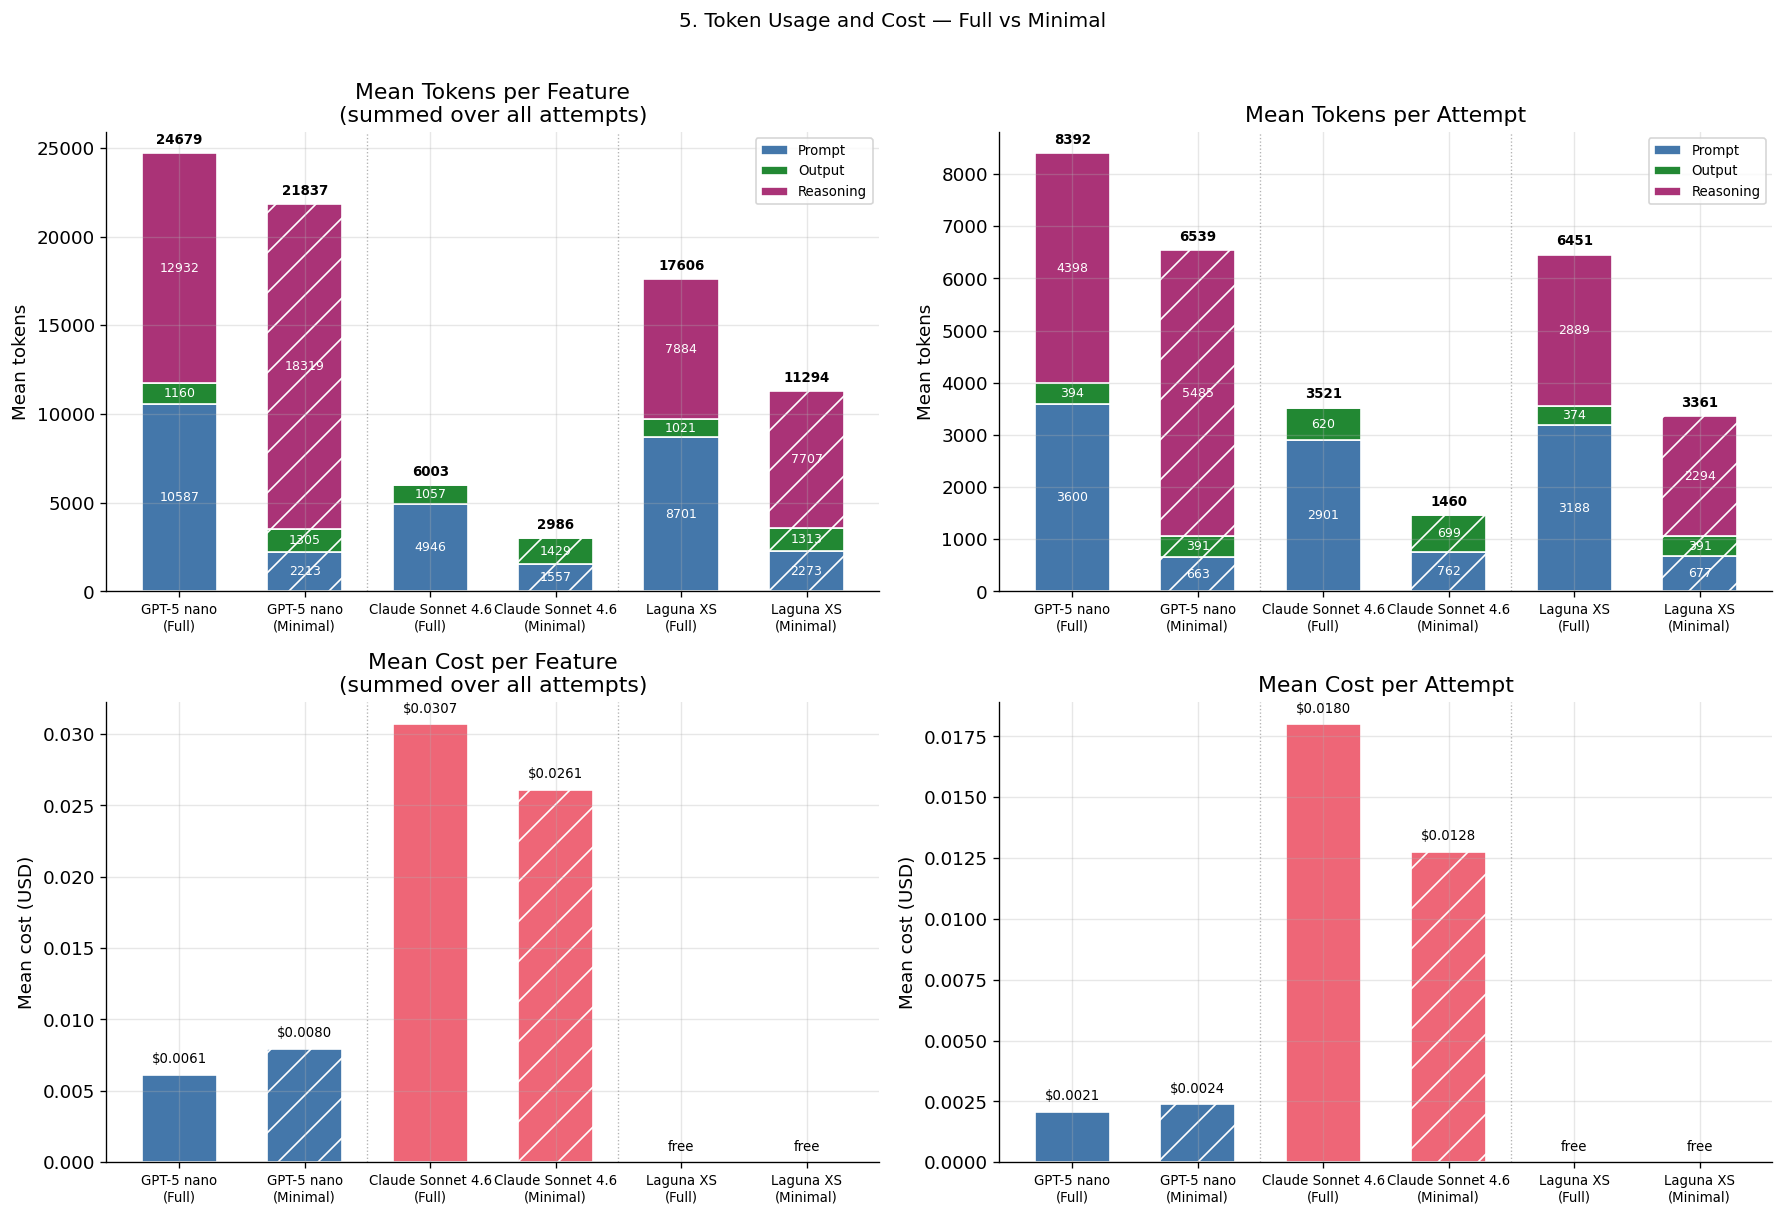

Token usage per feature (mean):
Model                         Ablation    prompt    output    reason
  GPT-5 nano                      Full     10587      1160     12932
  Claude Sonnet 4.6               Full      4946      1057         0
  Laguna XS                       Full      8701      1021      7884
  GPT-5 nano                   Minimal      2213      1305     18319
  Claude Sonnet 4.6            Minimal      1557      1429         0
  Laguna XS                    Minimal      2273      1313      7707

Cost per feature / per attempt (mean):
Model                         Ablation   per feat    per att
  GPT-5 nano                      Full    $0.0061    $0.0021
  Claude Sonnet 4.6               Full    $0.0307    $0.0180
  Laguna XS                       Full       free       free
  GPT-5 nano                   Minimal    $0.0080    $0.0024
  Claude Sonnet 4.6            Minimal    $0.0261    $0.0128
  Laguna XS                    Minimal       free       free


In [10]:
### 5.  Token Usage and Cost — Full vs Minimal
feat_rows_abl, att_rows_abl = [], []
for abl in ABLATIONS:
    for m in MODELS:
        for rec in data_ma[(m, abl)]:
            f_pt = f_out = f_rt = f_cost = 0
            for ix in rec.get("interactions") or []:
                a_pt = a_out = a_rt = a_cost = 0
                for s in ix.get("suggestions") or []:
                    pt   = s.get("prompt_tokens", 0) or 0
                    ct   = s.get("completion_tokens", 0) or 0
                    rt   = (s.get("completion_tokens_details") or {}).get("reasoning_tokens", 0) or 0
                    cost = s.get("cost", 0) or 0
                    a_pt  += pt;  a_out  += ct - rt;  a_rt  += rt;  a_cost  += cost
                    f_pt  += pt;  f_out  += ct - rt;  f_rt  += rt;  f_cost  += cost
                att_rows_abl.append({"model": m, "ablation": abl, "combo": f"{m}|{abl}",
                                     "prompt": a_pt, "output": a_out,
                                     "reasoning": a_rt, "cost": a_cost})
            feat_rows_abl.append({"model": m, "ablation": abl, "combo": f"{m}|{abl}",
                                   "prompt": f_pt, "output": f_out,
                                   "reasoning": f_rt, "cost": f_cost})

df_feat_abl = pd.DataFrame(feat_rows_abl)
df_att_abl  = pd.DataFrame(att_rows_abl)

combo_keys_tok   = [f"{m}|{abl}" for m in MODELS for abl in ABLATIONS]
combo_labels_tok = [f"{MODEL_LABELS[m]}\n({ABLATION_LABELS[abl]})"
                    for m in MODELS for abl in ABLATIONS]
x_tok = np.arange(len(combo_labels_tok))
tok_colors = {"prompt": "#4477AA", "output": "#228833", "reasoning": "#AA3377"}

def stacked_tok_bar_abl(ax, df, title):
    means = df.groupby("combo")[["prompt","output","reasoning"]].mean().reindex(combo_keys_tok)
    bottom = np.zeros(len(combo_keys_tok))
    for col, color in tok_colors.items():
        vals = means[col].values
        for xi, (v, b, hatch) in enumerate(zip(vals, bottom, combo_hatches)):
            ax.bar(xi, v, 0.6, bottom=b, color=color, hatch=hatch, edgecolor="white",
                   label=col.capitalize() if xi == 0 else None)
            if v > 80:
                ax.text(xi, b + v / 2, f"{v:.0f}", ha="center", va="center",
                        fontsize=7.5, color="white")
        bottom += vals
    for xi, total in enumerate(bottom):
        ax.text(xi, total + max(bottom) * 0.015, f"{total:.0f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
    for sep in [1.5, 3.5]:
        ax.axvline(sep, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_xticks(x_tok)
    ax.set_xticklabels(combo_labels_tok, fontsize=8)
    ax.set_ylabel("Mean tokens")
    ax.set_title(title)
    ax.legend(fontsize=8)

def cost_bar_abl(ax, df, title, ylabel):
    means = df.groupby("combo")["cost"].mean().reindex(combo_keys_tok)
    for xi, (v, color, hatch) in enumerate(zip(means.values, combo_colors, combo_hatches)):
        ax.bar(xi, v, 0.6, color=color, hatch=hatch, edgecolor="white")
        lbl = f"${v:.4f}" if v >= 0.0001 else "free"
        ax.text(xi, v + (max(means.values) or 1) * 0.02, lbl,
                ha="center", va="bottom", fontsize=8)
    for sep in [1.5, 3.5]:
        ax.axvline(sep, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_xticks(x_tok)
    ax.set_xticklabels(combo_labels_tok, fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
stacked_tok_bar_abl(axes[0, 0], df_feat_abl,
                    "Mean Tokens per Feature\n(summed over all attempts)")
stacked_tok_bar_abl(axes[0, 1], df_att_abl,
                    "Mean Tokens per Attempt")
cost_bar_abl(axes[1, 0], df_feat_abl,
             "Mean Cost per Feature\n(summed over all attempts)", "Mean cost (USD)")
cost_bar_abl(axes[1, 1], df_att_abl,
             "Mean Cost per Attempt", "Mean cost (USD)")

plt.suptitle("5. Token Usage and Cost — Full vs Minimal", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("analysis_5_tokens_cost.png", bbox_inches="tight")
plt.show()

print("Token usage per feature (mean):")
print(f"{'Model':<28}  {'Ablation':>8}  {'prompt':>8}  {'output':>8}  {'reason':>8}")
for abl in ABLATIONS:
    for m in MODELS:
        sub = df_feat_abl[(df_feat_abl["model"] == m) & (df_feat_abl["ablation"] == abl)]
        if sub.empty: continue
        print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  "
              f"{sub.prompt.mean():>8.0f}  {sub.output.mean():>8.0f}  {sub.reasoning.mean():>8.0f}")
print("\nCost per feature / per attempt (mean):")
print(f"{'Model':<28}  {'Ablation':>8}  {'per feat':>9}  {'per att':>9}")
for abl in ABLATIONS:
    for m in MODELS:
        sf = df_feat_abl[(df_feat_abl["model"] == m) & (df_feat_abl["ablation"] == abl)]
        sa = df_att_abl[ (df_att_abl["model"]  == m) & (df_att_abl["ablation"]  == abl)]
        if sf.empty: continue
        cf = sf.cost.mean(); ca = sa.cost.mean()
        print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  "
              f"{'free' if cf == 0 else f'${cf:.4f}':>9}  "
              f"{'free' if ca == 0 else f'${ca:.4f}':>9}")

---

## 6. Prompt Example — Full vs Minimal

Shows the actual prompts sent to the LLM for one feature, both ablations.
System and user message boundaries are displayed explicitly.

In [11]:
import re as _re

def _split_prompt(prompt):
    """
    Split a prompt (str or list-of-messages) into [(role, content), ...].

    Handles two formats:
      • list of {"role": ..., "content": ...} dicts  (OpenAI messages API)
      • flat string with 'System:', 'User:', 'Assistant:' section headers
        at the start of a line (the format used in these experiments)
    """
    if isinstance(prompt, list):
        return [(msg.get("role", "unknown"),
                 msg.get("content", "") if isinstance(msg.get("content"), str)
                 else "\n".join((p.get("text","") if isinstance(p,dict) else str(p))
                                for p in msg.get("content",[])))
                for msg in prompt]

    if isinstance(prompt, str):
        pattern = _re.compile(r'^(System|User|Assistant):\s?', _re.MULTILINE)
        parts = pattern.split(prompt)
        # parts = ['', 'System', 'text...', 'User', 'text...', ...]
        # or ['preamble', 'System', 'text...', ...] if there's content before first header
        roles, texts = [], []
        i = 0
        if parts[0].strip():          # content before first header — treat as preamble
            roles.append("(preamble)")
            texts.append(parts[0].rstrip())
            i = 1
        else:
            i = 1                     # skip the empty leading string
        while i + 1 < len(parts):
            roles.append(parts[i].lower())
            texts.append(parts[i + 1].rstrip())
            i += 2
        return list(zip(roles, texts))

    return [("unknown", repr(prompt))]


def show_prompt_pair(m, feature_idx=0):
    """Print interaction-0 prompts for both ablations of a given model."""
    r_full = data_ma[(m, "full")][feature_idx]
    key = (r_full["dataset"], r_full["class_name"], r_full["feature_name"])
    r_min = next(
        (r for r in data_ma[(m, "minimal")]
         if (r["dataset"], r["class_name"], r["feature_name"]) == key),
        None,
    )
    if r_min is None:
        print("Feature not found in minimal ablation — try a different index.")
        return

    print(f"Model  : {MODEL_LABELS[m]}")
    print(f"Dataset: {key[0]}   Class: {key[1]}   Feature: {key[2]}")

    W = 90
    for abl, rec in [("full", r_full), ("minimal", r_min)]:
        ix = (rec.get("interactions") or [{}])[0]
        prompt = ix.get("prompt") or ix.get("messages") or []

        print(f"\n{'█' * W}")
        print(f"  ABLATION: {ABLATION_LABELS[abl].upper()}  ({abl})")
        print(f"{'█' * W}")

        if not prompt:
            print("  (no prompt recorded)")
            continue

        for role, content in _split_prompt(prompt):
            print(f"\n{'─' * W}")
            print(f"  ▶  {role.upper()}")
            print(f"{'─' * W}")
            print(content)

    print(f"\n{'═' * W}")


# Show the first common feature for the first model.
# Change feature_idx or m to browse other examples.
show_prompt_pair(MODELS[0], feature_idx=0)

Model  : GPT-5 nano
Dataset: buggy-java-jml-eiffel   Class: LCM_1   Feature: div

██████████████████████████████████████████████████████████████████████████████████████████
  ABLATION: FULL  (full)
██████████████████████████████████████████████████████████████████████████████████████████

──────────────────────────────────────────────────────────────────────────────────────────
  ▶  SYSTEM
──────────────────────────────────────────────────────────────────────────────────────────
You are a coding assistant, expert in the Eiffel programming language and AutoProof static verifier.
You will receive context about a class followed by an Eiffel feature that does not verify, and the AutoProof error.
Respond with a corrected version of the feature.
IMPORTANT: You must ONLY modify the feature body (the code between 'do' and 'end') and/or the local variable declarations (the 'local' clause).
You must NOT modify:
- The feature signature (name, parameters, return type)
- Notes (the 'note' clause)
-